# **Business Context and Problem Definition**

## Business Context

With the increasing popularity and ease of access to online hotel booking platforms, customers tend to make reservations in advance to avoid any last-minute rush and higher prices. These online platforms offer flexible cancellation options, in some cases even a day before reservation. To compete with this, even offline bookings have increased the flexibility in cancellations. This has led to an increase in the growing number of cancellations, with one of the primary reasons being last-minute changes in travel plans. These sudden changes can result from unforeseen circumstances, such as personal emergencies, flight delays, or unexpected events at the travel destination.

Hotel booking cancellations become a crucial problem to solve as it leads to revenue loss and operational inefficiencies. The cancellation of bookings impacts a hotel on various fronts:

1. Loss of revenue when the hotel cannot resell the room

2. Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms

3. Lowering prices last minute, so the hotel can resell a room, resulting in reduced profit margins

## Problem Definition

The INN Hotels Group has been contending with the challenge of rising cancellations for nearly a year now. However, the last three months witnessed a **rise in inventory loss due to cancellation rise to an all-time high of 18%**. This has led to a jump in the **revenue loss to an all-time high of approx. \$0.25 million annually**. This has significantly impacted their profit margins.

- In the current context, inventory refers to a hotel room, and the inability to sell one leads to inventory loss

The group has been using heuristic mechanisms (rule and domain expert-based) to try and reduce the revenue loss due to cancellations, but this hasn't been effective so far hasn't been effective (neither efficient nor scalable), as evident from the magnitude of losses they are incurring.

The group has decided that they **need a Data Science-based solution to predict the likelihood of a booking being canceled** as they expect it to be more effective than their current mechanism. They hope that this proactive approach will help them significantly **minimize revenue loss and improve operational efficiency**.

In [133]:
# Lets import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import PowerTransformer




import warnings
warnings.filterwarnings('ignore')

In [134]:
# Lets load the data
past_data = pd.read_csv('INNHotelsGroup_pastdata.csv')
new_data = pd.read_csv('INNHotelsGroup_newdata.csv')

In [135]:
past_data.head(2)

,booking_id,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status,rebooked
0,INNHG_101034,0,Online,0,85.03,1,1,2021-01-01,0,0,Not Canceled,NaN
1,INNHG_101035,34,Online,2,125.10,2,2,2021-01-01,0,0,Not Canceled,NaN


In [136]:
new_data.head(2)

,booking_id,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status
0,INNHG_128127,4,Online,1,103.0,1,0,2022-07-01,1,1,Not Canceled
1,INNHG_128128,147,Online,2,103.7,2,2,2022-07-01,0,2,Not Canceled


### Lets understand exactly how many bookings were canceled and rebooked 

In [138]:
# Lets see hoew bookings were cancelled at last moment.
past_data['booking_status'].value_counts(normalize=True)

booking_status
Not Canceled    0.673089
Canceled        0.326911
Name: proportion, dtype: float64

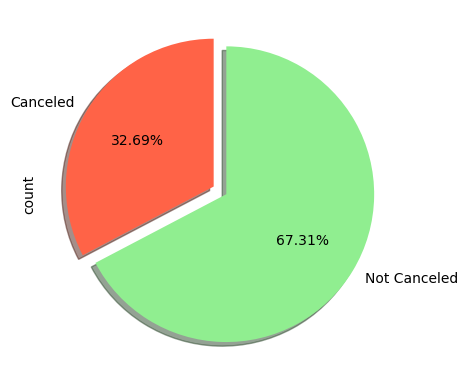

In [139]:
past_data['booking_status'].value_counts().plot(kind='pie',colors=['lightgreen','tomato'],
                                               autopct='%.2f%%',counterclock=False,startangle=90,
                                               explode=[0,0.1],shadow=True)
plt.show()

In [140]:
# Lets see out of cancelled bookings how many were rebooked
past_data[past_data['booking_status']=='Canceled']['rebooked']\
.value_counts(normalize=True)

rebooked
No     0.800723
Yes    0.199277
Name: proportion, dtype: float64

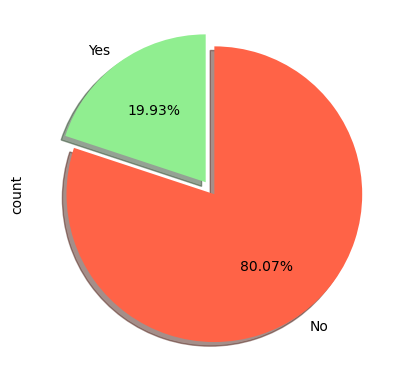

In [141]:
past_data[past_data['booking_status']=='Canceled']['rebooked']\
.value_counts().plot(kind='pie',colors=['tomato','lightgreen'],
                    autopct='%.2f%%',counterclock=False,startangle=90,
                    explode=[0,0.1],shadow=True)
plt.show()

Inference: Here we can see that out of all the bookings ~33% bookings are being  cancelled at last moment and out of those cancelled bookings only ~20% were rebooked. Which leads to huge inventory loss.

In [143]:
# We can remove the "rebooked" from data as this information will not 
# be available beforehand.

past_data.drop(columns='rebooked',inplace=True)

In [144]:
past_data.head(2)

,booking_id,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status
0,INNHG_101034,0,Online,0,85.03,1,1,2021-01-01,0,0,Not Canceled
1,INNHG_101035,34,Online,2,125.10,2,2,2021-01-01,0,0,Not Canceled


In [145]:
# We can also make booking id as index column/ or remove as these are just 
# unique  identifiers of bookings (rows)

past_data.set_index('booking_id',inplace=True)
new_data.set_index('booking_id',inplace=True)

In [146]:
past_data.head(2)

,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status
booking_id,,,,,,,,,,
INNHG_101034,0,Online,0,85.03,1,1,2021-01-01,0,0,Not Canceled
INNHG_101035,34,Online,2,125.10,2,2,2021-01-01,0,0,Not Canceled


In [147]:
new_data.head(2)

,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status
booking_id,,,,,,,,,,
INNHG_128127,4,Online,1,103.0,1,0,2022-07-01,1,1,Not Canceled
INNHG_128128,147,Online,2,103.7,2,2,2022-07-01,0,2,Not Canceled


### Explore the data

In [149]:
print('No. of Rows',past_data.shape[0])
print('No. of Columns',past_data.shape[1])

No. of Rows 27093
No. of Columns 10


In [150]:
# Check the balance of target variable
past_data['booking_status'].value_counts(normalize=True)

booking_status
Not Canceled    0.673089
Canceled        0.326911
Name: proportion, dtype: float64

In [151]:
# Five point summary
past_data.describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,27093.0,81.605249,84.901428,0.0,14.0,55.0,118.0,443.0
no_of_special_requests,27093.0,0.556454,0.743715,0.0,0.0,0.0,1.0,5.0
avg_price_per_room,27093.0,101.025910,34.557289,0.0,79.0,97.0,119.0,540.0
no_of_adults,27093.0,1.825822,0.512182,0.0,2.0,2.0,2.0,4.0
no_of_weekend_nights,27093.0,0.778319,0.861787,0.0,0.0,1.0,1.0,6.0
required_car_parking_space,27093.0,0.028864,0.167426,0.0,0.0,0.0,0.0,1.0
no_of_week_nights,27093.0,2.171373,1.386023,0.0,1.0,2.0,3.0,17.0


In [152]:
past_data.columns

Index(['lead_time', 'market_segment_type', 'no_of_special_requests',
       'avg_price_per_room', 'no_of_adults', 'no_of_weekend_nights',
       'arrival_date', 'required_car_parking_space', 'no_of_week_nights',
       'booking_status'],
      dtype='object')

In [153]:
# Explore the columns one by one
num_cols = ['lead_time','avg_price_per_room','no_of_week_nights']
cat_cols = ['market_segment_type', 'no_of_special_requests',
           'no_of_adults', 'no_of_weekend_nights','required_car_parking_space',
           'booking_status']

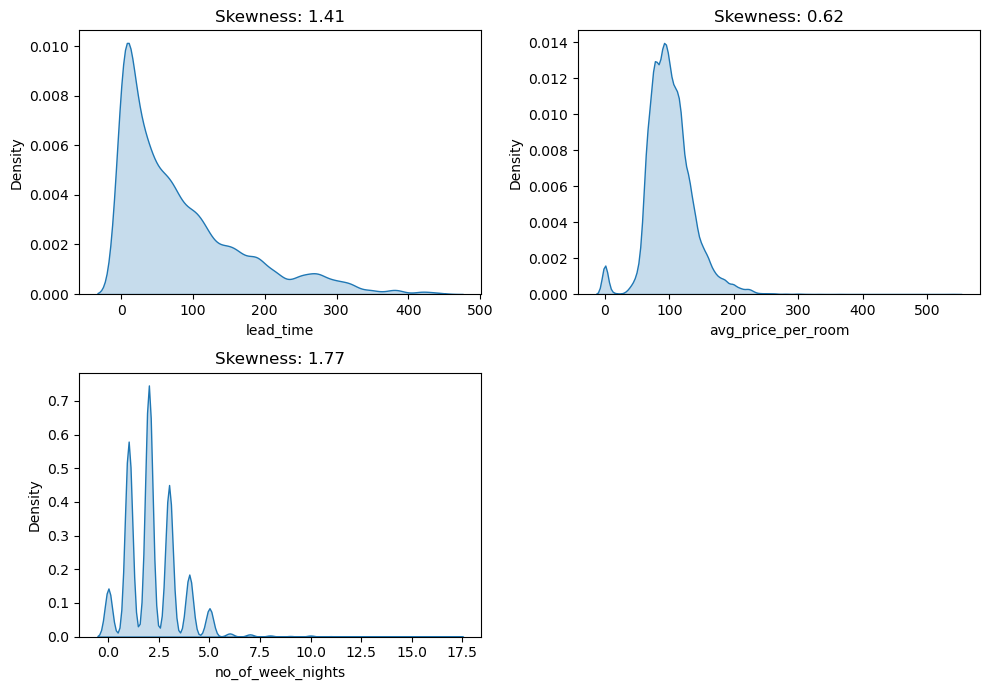

In [154]:
# Univariate Analysis

t=1
plt.figure(figsize=(10,7))
for i in num_cols:
    plt.subplot(2,2,t)
    plt.title(f'Skewness: {round(past_data[i].skew(),2)}')
    sns.kdeplot(data=past_data,x=i,fill=True)
    t+=1
plt.tight_layout()
plt.show()

Inference:

* Lead time is exceeding 300 days!!! are there bookings which have been made 1 year prior?

* There are bookings with avg price per room 0.

* There are customers with very long stays upto 17 weeknights.

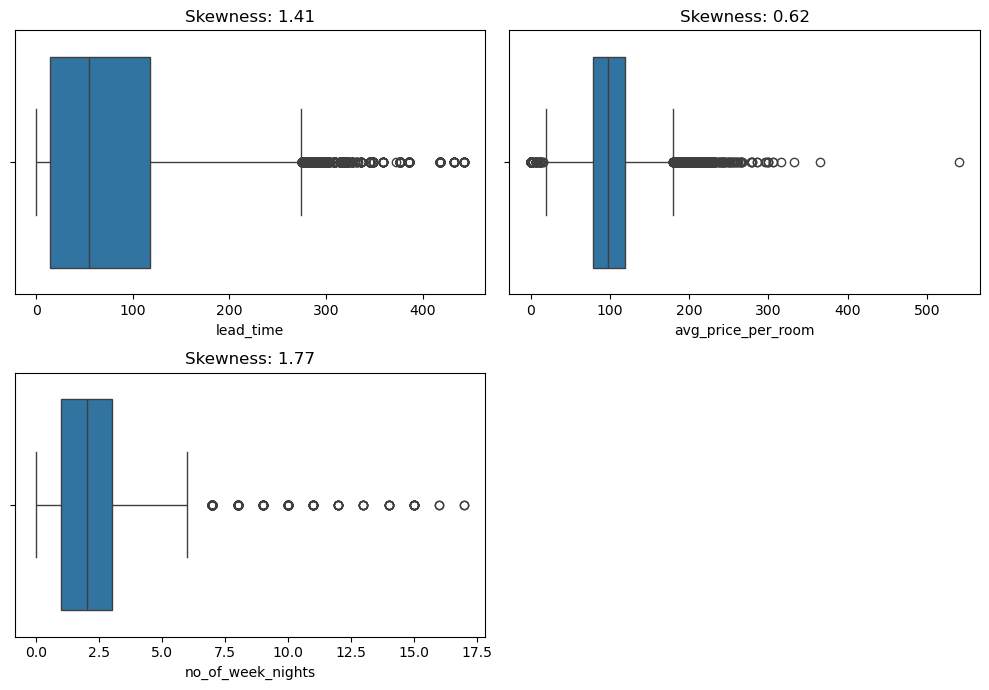

In [156]:
t=1
plt.figure(figsize=(10,7))
for i in num_cols:
    plt.subplot(2,2,t)
    plt.title(f'Skewness: {round(past_data[i].skew(),2)}')
    sns.boxplot(data=past_data,x=i)
    t+=1
plt.tight_layout()
plt.show()

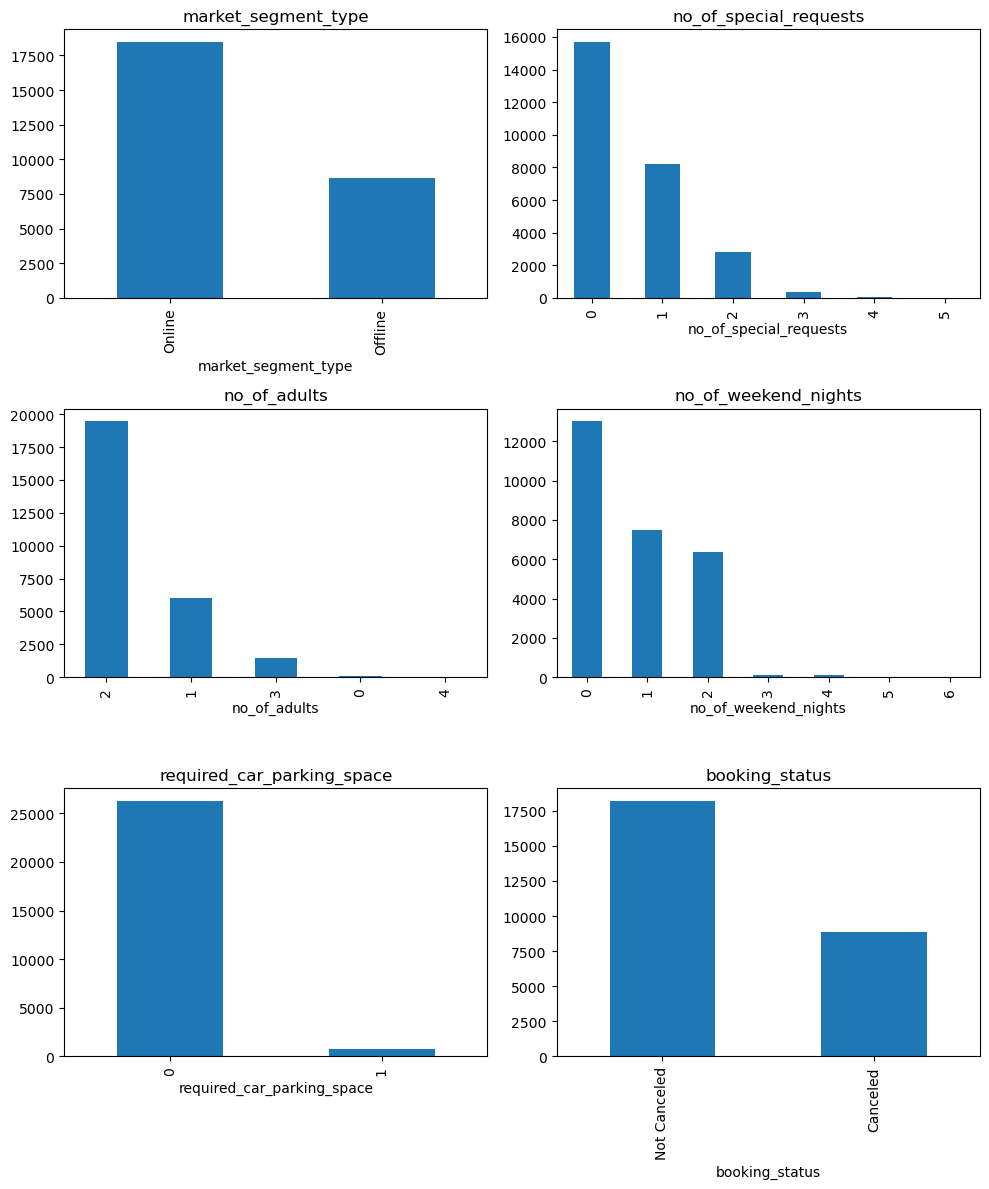

In [157]:
t=1
plt.figure(figsize=(10,12))
for i in cat_cols:
    plt.subplot(3,2,t)
    past_data[i].value_counts().plot(kind='bar')
    plt.title(i)
    t+=1
plt.tight_layout()
plt.show()

Inference:

* Most of the bookings have been made online.
* Mostly there are no or 1 special requests.
* In most of the bookings no. of adults are 1 or 2.
* In most of the bookings maximum weekend nights are 2.
* In most the bookings do not require parking space.

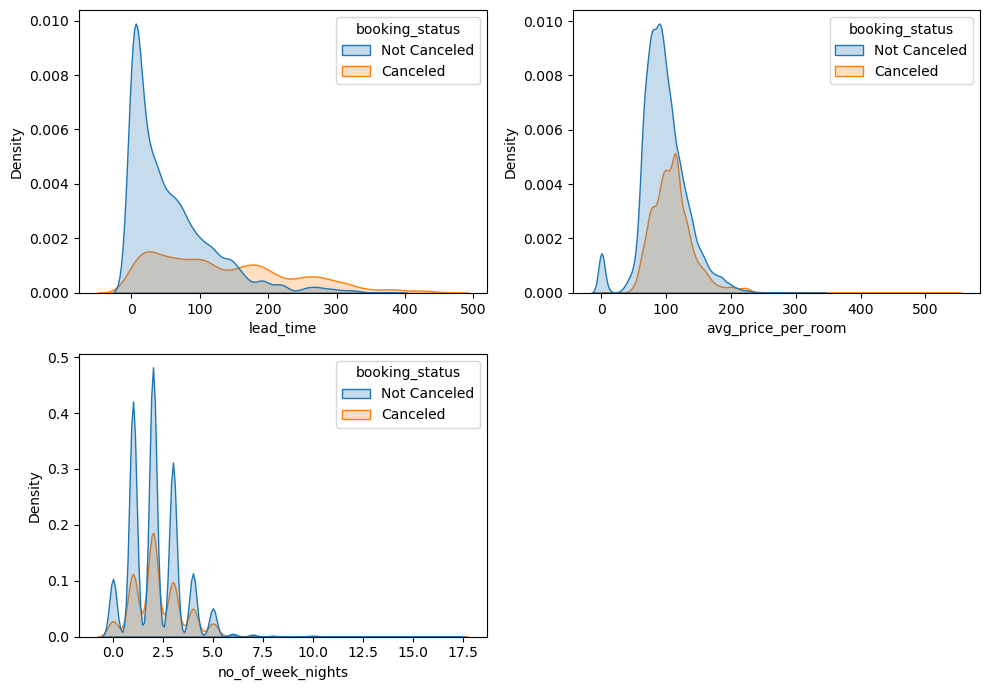

In [159]:
# Bivariate Analysis

t=1
plt.figure(figsize=(10,7))
for i in num_cols:
    plt.subplot(2,2,t)
    sns.kdeplot(data=past_data,x=i,fill=True,hue='booking_status')
    t+=1
plt.tight_layout()
plt.show()

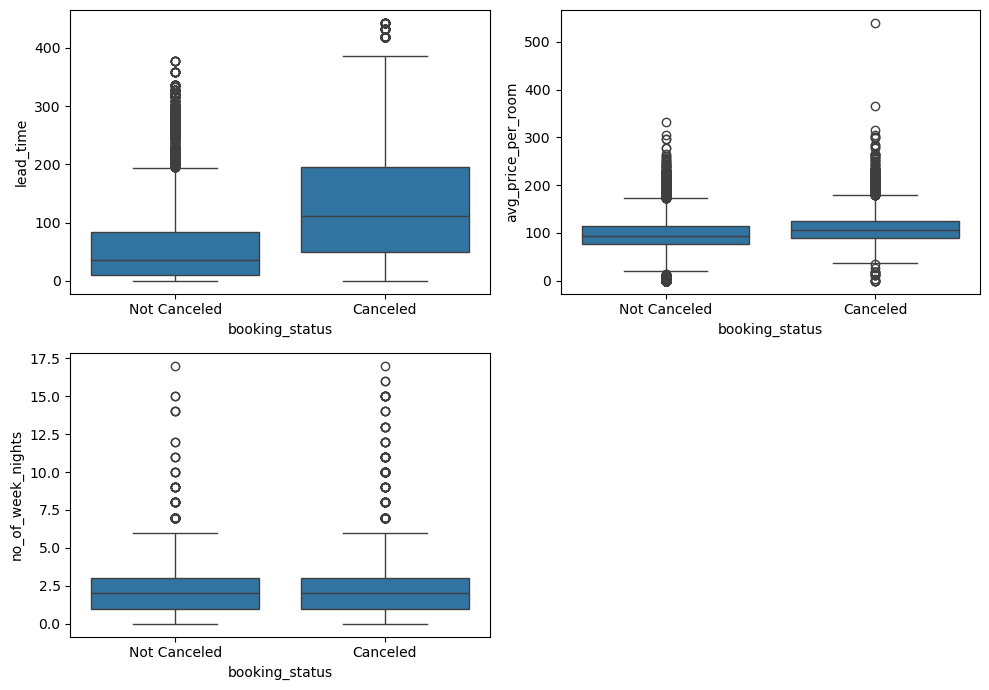

In [160]:
t=1
plt.figure(figsize=(10,7))
for i in num_cols:
    plt.subplot(2,2,t)
    sns.boxplot(data=past_data,x='booking_status',y=i)
    t+=1
plt.tight_layout()
plt.show()

In [161]:
# Lets investigate lead_time and avg_price_per_room with booking status
past_data.groupby(by='booking_status')['lead_time'].mean()

booking_status
Canceled        134.035791
Not Canceled     56.140382
Name: lead_time, dtype: float64

In [162]:
samp1 = past_data[past_data['booking_status']=='Canceled']['lead_time']
samp2 = past_data[past_data['booking_status']=='Not Canceled']['lead_time']

In [163]:
# We will go with 2 sample t-test
# Assumption 1: Data must be normal
print(stats.shapiro(samp1))
print(stats.shapiro(samp2))

# Assumption 2: Variances are equal
print(stats.levene(samp1,samp2))

# Data is not normal and varaiances are also not equal

ShapiroResult(statistic=0.9387743609879114, pvalue=4.865435517353332e-51)
ShapiroResult(statistic=0.8214888949700189, pvalue=7.235137959871973e-88)
LeveneResult(statistic=3210.120590252021, pvalue=0.0)


In [164]:
# Lets go with non parametric test (Mannwhineyu Test)
pvalue =  stats.mannwhitneyu(samp1,samp2,alternative='greater')[1]

if pvalue < 0.05:
    print('Reject Ho:')
else:
    print('Fail to reject Ho:')
    
# We can conclude that avg_lead_time of canceled bokings are greater than
# not calceled bookings with 95% confidence level.

Reject Ho:


In [165]:
# Avg_price vs booking status
past_data.groupby('booking_status')['avg_price_per_room'].mean()

booking_status
Canceled        109.722152
Not Canceled     96.802253
Name: avg_price_per_room, dtype: float64

In [166]:
# mu1 -> Avg price of canceled, mu2 -> avg price not canceled bookings
# Ho: mu1 <= mu2
# Ha: mu1 > mu2
samp1 = past_data[past_data['booking_status']=='Canceled']['avg_price_per_room']
samp2 = past_data[past_data['booking_status']=='Not Canceled']['avg_price_per_room']

pvalue =  stats.mannwhitneyu(samp1,samp2,alternative='greater')[1]

if pvalue < 0.05:
    print('Reject Ho:')
else:
    print('Fail to reject Ho:')
    
# hence we can conclude the avg price of canceled booking is greater than 
# not canceled bookings.

Reject Ho:


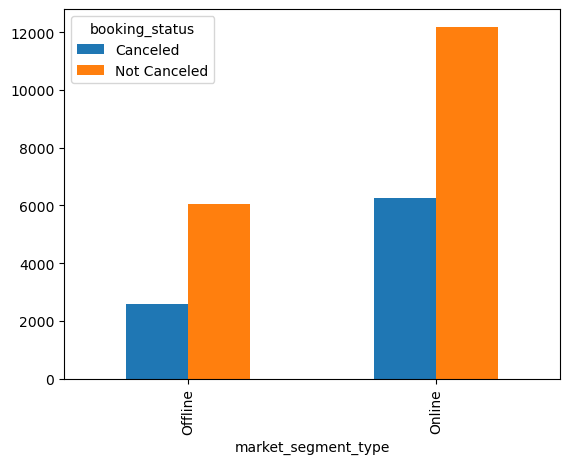

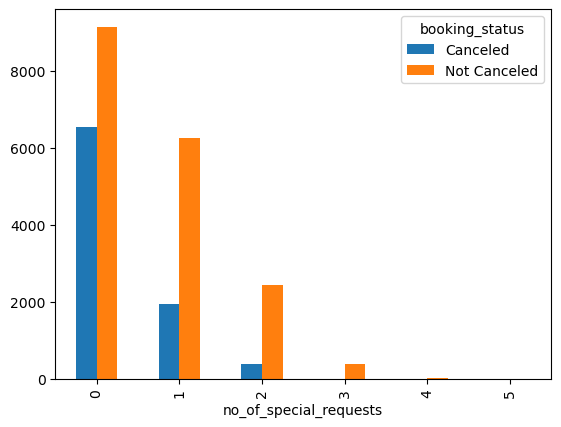

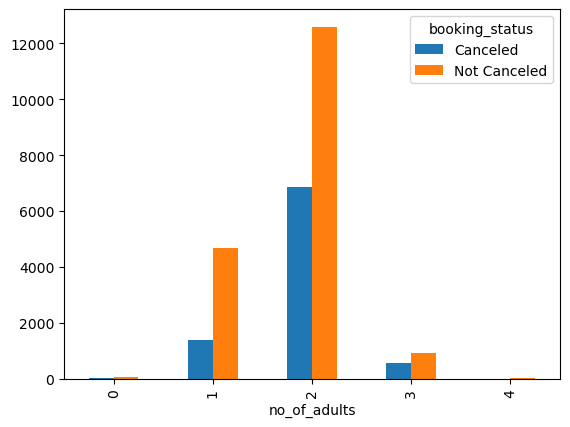

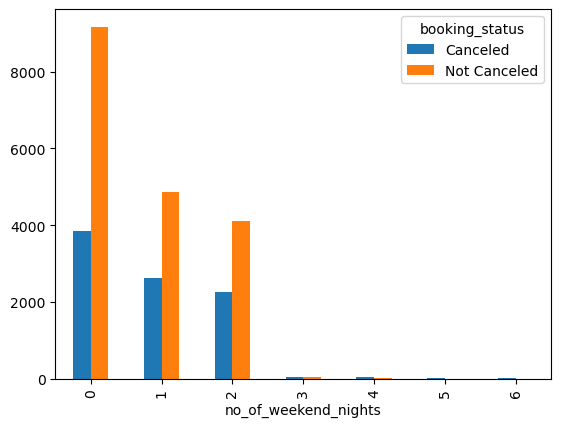

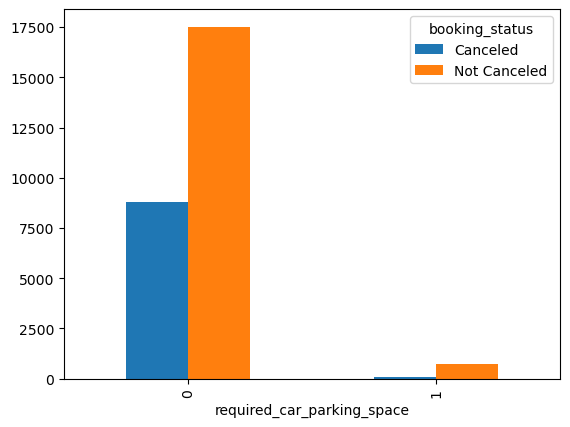

In [167]:
# Cat columns vs target variable

for i in cat_cols:
    if i != 'booking_status':
        pd.crosstab(past_data[i],past_data['booking_status']).plot(kind='bar')
    plt.show()

In [168]:
# Lets do chi-square contingency test to make final conclusions
# H0: Columns are independent
# H1: Columns are dependent

for i in cat_cols:
    if i!='booking_status':
        contingency_table = pd.crosstab(past_data[i],past_data['booking_status'])
        print(i,':',stats.chi2_contingency(contingency_table)[1])
        
# We reject Ho: in all the cases as p_value is less than 0.05

market_segment_type : 7.806389643886697e-11
no_of_special_requests : 0.0
no_of_adults : 1.4411855115006094e-73
no_of_weekend_nights : 5.324997086476798e-43
required_car_parking_space : 5.626905783478662e-49


Inference:

* Target variable is affected by all the categorical columns.

#### (Just for reference)

Inferential Statistcis (Num Vs Num)

In [171]:
past_data['lead_time'].corr(past_data['avg_price_per_room'])

-0.029289187268519885

In [172]:
# Parametric tets  (Person's Correlation test)
# Assumption: Data must be normal

# Ho: No correlation
# Ha: Correlation

stats.pearsonr(past_data['lead_time'],past_data['avg_price_per_room'])

PearsonRResult(statistic=-0.029289187268519916, pvalue=1.4227003552821461e-06)

In [173]:
# Non Parametric tets  (Spearman's Correlation test)

# Ho: No correlation
# Ha: Correlation

stats.spearmanr(past_data['lead_time'],past_data['avg_price_per_room'])

SignificanceResult(statistic=0.00683549727618094, pvalue=0.26055481328066965)

## Data Preprocessing

In [175]:
# Check for duplicates

past_data.duplicated().sum()

8438

In [176]:
# Although it shows duplicates but each row has its own booking_id, so we will
# assume there are no duplicates

In [177]:
# Check for missing values
past_data.isnull().sum().sum()

0

In [178]:
new_data.isnull().sum().sum()

0

In [179]:
# Check for Outliers

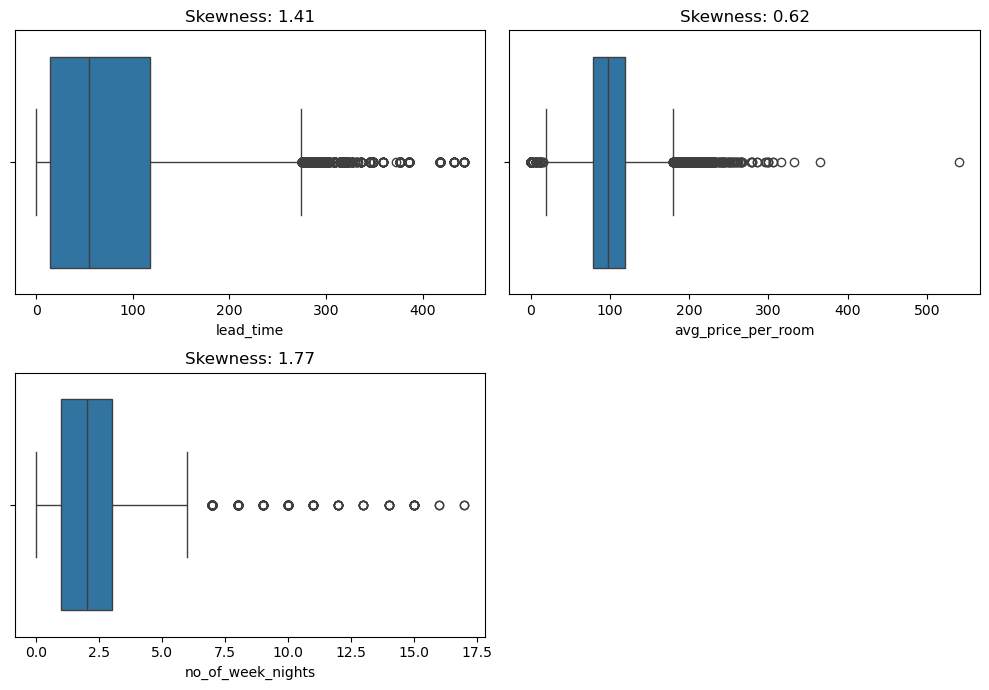

In [180]:
t=1
plt.figure(figsize=(10,7))
for i in num_cols:
    plt.subplot(2,2,t)
    plt.title(f'Skewness: {round(past_data[i].skew(),2)}')
    sns.boxplot(data=past_data,x=i)
    t+=1
plt.tight_layout()
plt.show()

In [181]:
# For now lets treat only the xtreme outlier in avg_price_per_room
for col in num_cols:
    q1, q3 = np.quantile(past_data[col], [0.25, 0.75])
    iqr = q3 - q1
    upper_limit = q3 + 2.2 * iqr
    lower_limit = q1 - 2.2 * iqr
    
    # Apply capping to both past and new data
    past_data[col] = past_data[col].clip(lower_limit, upper_limit)
    new_data[col] = new_data[col].clip(lower_limit, upper_limit)

print("Outliers have been capped using the 2 X IQR value.")

Outliers have been capped using the 2 X IQR value.


In [182]:
past_data.drop(index='INNHG_119173',inplace=True)

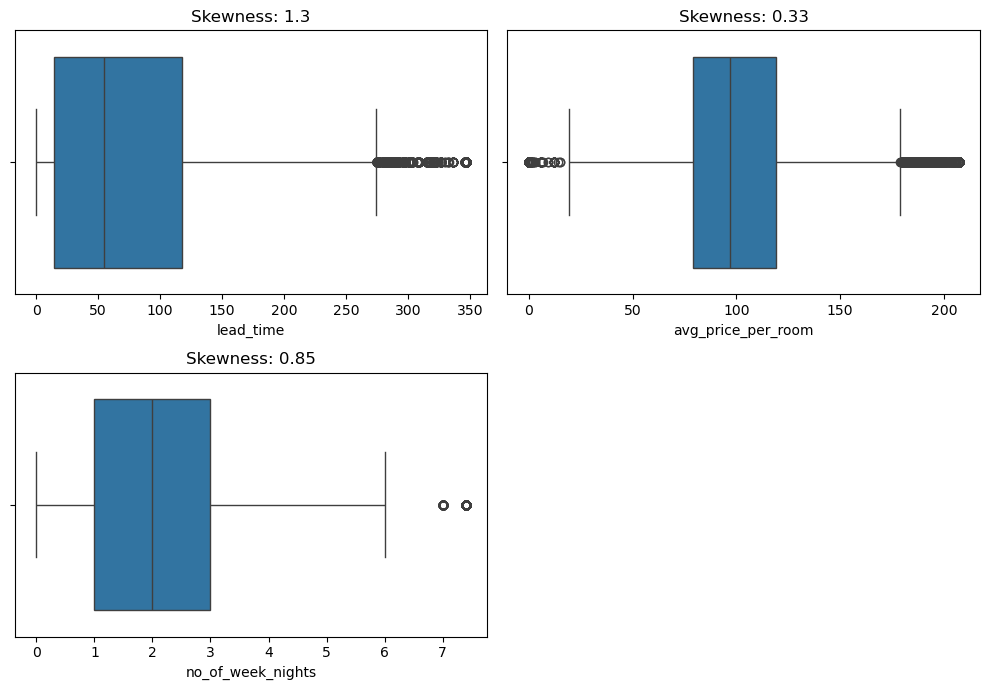

In [183]:
t=1
plt.figure(figsize=(10,7))
for i in num_cols:
    plt.subplot(2,2,t)
    plt.title(f'Skewness: {round(past_data[i].skew(),2)}')
    sns.boxplot(data=past_data,x=i)
    t+=1
plt.tight_layout()
plt.show()

In [184]:
# Split the data in train and test before we do any transformation

X_train = past_data.drop(columns=['booking_status'])
y_train = past_data['booking_status'].map({'Not Canceled':0,'Canceled':1})

X_test = new_data.drop(columns=['booking_status'])
y_test = new_data['booking_status'].map({'Not Canceled':0,'Canceled':1})

In [185]:
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(27092, 9) (27092,) (3583, 9) (3583,)


### Feature Encoding and Engineering

In [187]:
X_train.dtypes

lead_time                     float64
market_segment_type            object
no_of_special_requests          int64
avg_price_per_room            float64
no_of_adults                    int64
no_of_weekend_nights            int64
arrival_date                   object
required_car_parking_space      int64
no_of_week_nights             float64
dtype: object

In [188]:
X_train['market_segment_type'].value_counts()

market_segment_type
Online     18456
Offline     8636
Name: count, dtype: int64

In [189]:
X_train['market_segment_type'] = X_train['market_segment_type']\
.map({'Online':1,'Offline':0})

X_test['market_segment_type'] = X_test['market_segment_type']\
.map({'Online':1,'Offline':0})

In [190]:
X_train['market_segment_type'].value_counts()

market_segment_type
1    18456
0     8636
Name: count, dtype: int64

In [191]:
X_test['market_segment_type'].value_counts()

market_segment_type
1    3105
0     478
Name: count, dtype: int64

In [193]:
X_train['arrival_date'] = pd.to_datetime(X_train['arrival_date'])
X_test['arrival_date'] = pd.to_datetime(X_test['arrival_date'])

In [194]:
X_train['arrival_month'] = X_train['arrival_date'].dt.month
X_train['arrival_day'] = X_train['arrival_date'].dt.day
X_train['arrival_weekday'] = X_train['arrival_date'].dt.weekday

In [195]:
X_test['arrival_month'] = X_test['arrival_date'].dt.month
X_test['arrival_day'] = X_test['arrival_date'].dt.day
X_test['arrival_weekday'] = X_test['arrival_date'].dt.weekday

In [196]:
def engineer_features(df):
    # 1. is_weekend_stay
    df['is_weekend_stay'] = (df['no_of_weekend_nights'] > 0).astype(int)
    
    # 2. booking_window
    bins = [-1, 7, 30, 90, 180, 365, float('inf')]
    labels = ['Last Week', 'Within a Month', '1-3 Months', '3-6 Months', '6-12 Months', 'More than a Year']
    df['booking_window'] = pd.cut(df['lead_time'], bins=bins, labels=labels)
    
    # 3. party_type
    def get_party_type(n_adults):
        if n_adults == 1:
            return 'Solo'
        elif n_adults == 2:
            return 'Couple/NOT SOLO'
        else:
            return 'Group'
    df['party_type'] = df['no_of_adults'].apply(get_party_type)
    
    return df

X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

print("New features 'is_weekend_stay', 'booking_window', and 'party_type' created.")
past_data.head()

New features 'is_weekend_stay', 'booking_window', and 'party_type' created.


,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,booking_status
booking_id,,,,,,,,,,
INNHG_101034,0.0,Online,0,85.03,1,1,2021-01-01,0,0.0,Not Canceled
INNHG_101035,34.0,Online,2,125.10,2,2,2021-01-01,0,0.0,Not Canceled
INNHG_101036,24.0,Online,1,71.69,2,2,2021-01-01,0,0.0,Not Canceled
INNHG_101037,23.0,Online,0,84.70,1,2,2021-01-01,0,0.0,Not Canceled
INNHG_101038,46.0,Online,1,149.40,2,2,2021-01-01,0,3.0,Canceled


In [197]:
X_train.head()

,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,arrival_month,arrival_day,arrival_weekday,is_weekend_stay,booking_window,party_type
booking_id,,,,,,,,,,,,,,,
INNHG_101034,0.0,1,0,85.03,1,1,2021-01-01,0,0.0,1,1,4,1,Last Week,Solo
INNHG_101035,34.0,1,2,125.10,2,2,2021-01-01,0,0.0,1,1,4,1,1-3 Months,Couple/NOT SOLO
INNHG_101036,24.0,1,1,71.69,2,2,2021-01-01,0,0.0,1,1,4,1,Within a Month,Couple/NOT SOLO
INNHG_101037,23.0,1,0,84.70,1,2,2021-01-01,0,0.0,1,1,4,1,Within a Month,Solo
INNHG_101038,46.0,1,1,149.40,2,2,2021-01-01,0,3.0,1,1,4,1,1-3 Months,Couple/NOT SOLO


In [198]:
# One-hot encode the new categorical features
cat_features_to_encode = ['booking_window', 'party_type']

X_train = pd.get_dummies(X_train, columns=cat_features_to_encode, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=cat_features_to_encode, drop_first=True, dtype=int)




print("Head of past_data after encoding:", X_train.head())
print("Head of new_data after encoding:", X_test.head())

Head of past_data after encoding:               lead_time  market_segment_type  no_of_special_requests  \
booking_id                                                             
INNHG_101034        0.0                    1                       0   
INNHG_101035       34.0                    1                       2   
INNHG_101036       24.0                    1                       1   
INNHG_101037       23.0                    1                       0   
INNHG_101038       46.0                    1                       1   

              avg_price_per_room  no_of_adults  no_of_weekend_nights  \
booking_id                                                             
INNHG_101034               85.03             1                     1   
INNHG_101035              125.10             2                     2   
INNHG_101036               71.69             2                     2   
INNHG_101037               84.70             1                     2   
INNHG_101038              149

In [199]:
X_test.head()

,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,arrival_month,arrival_day,arrival_weekday,is_weekend_stay,booking_window_Within a Month,booking_window_1-3 Months,booking_window_3-6 Months,booking_window_6-12 Months,booking_window_More than a Year,party_type_Group,party_type_Solo
booking_id,,,,,,,,,,,,,,,,,,,,
INNHG_128127,4,1,1,103.00,1,0,2022-07-01,1,1.0,7,1,4,0,0,0,0,0,0,0,1
INNHG_128128,147,1,2,103.70,2,2,2022-07-01,0,2.0,7,1,4,1,0,0,1,0,0,0,0
INNHG_128129,43,1,1,126.90,2,1,2022-07-01,1,2.0,7,1,4,1,0,1,0,0,0,0,0
INNHG_128130,145,0,0,72.76,2,0,2022-07-01,0,1.0,7,1,4,0,0,0,1,0,0,0,0
INNHG_128131,86,0,1,107.69,2,1,2022-07-01,0,2.0,7,1,4,1,0,1,0,0,0,0,0


In [200]:
X_train.head()

,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,arrival_month,arrival_day,arrival_weekday,is_weekend_stay,booking_window_Within a Month,booking_window_1-3 Months,booking_window_3-6 Months,booking_window_6-12 Months,booking_window_More than a Year,party_type_Group,party_type_Solo
booking_id,,,,,,,,,,,,,,,,,,,,
INNHG_101034,0.0,1,0,85.03,1,1,2021-01-01,0,0.0,1,1,4,1,0,0,0,0,0,0,1
INNHG_101035,34.0,1,2,125.10,2,2,2021-01-01,0,0.0,1,1,4,1,0,1,0,0,0,0,0
INNHG_101036,24.0,1,1,71.69,2,2,2021-01-01,0,0.0,1,1,4,1,1,0,0,0,0,0,0
INNHG_101037,23.0,1,0,84.70,1,2,2021-01-01,0,0.0,1,1,4,1,1,0,0,0,0,0,1
INNHG_101038,46.0,1,1,149.40,2,2,2021-01-01,0,3.0,1,1,4,1,0,1,0,0,0,0,0


In [201]:
#Make sure train & test columns match
X_train, X_test = X_train.align(X_test, join="outer", axis=1, fill_value=0)
#This ensures both have the same dummy variables.

In [202]:
from sklearn.preprocessing import PowerTransformer, StandardScaler

# Re-define numerical columns after feature engineering
num_cols = X_test.select_dtypes(include=np.number).columns.tolist()
if 'booking_status' in num_cols:
    num_cols.remove('booking_status')

# 1. Power Transformation
pt = PowerTransformer(standardize=False)
X_train[num_cols] = pt.fit_transform(X_train[num_cols])
X_test[num_cols] = pt.transform(X_test[num_cols])

# 2. Scaling
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Data transformation and scaling complete.")

Data transformation and scaling complete.


In [203]:
X_train.head()

,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,arrival_month,arrival_day,arrival_weekday,is_weekend_stay,booking_window_Within a Month,booking_window_1-3 Months,booking_window_3-6 Months,booking_window_6-12 Months,booking_window_More than a Year,party_type_Group,party_type_Solo
booking_id,,,,,,,,,,,,,,,,,,,,
INNHG_101034,-1.901716,0.684049,-0.843743,-0.454095,-1.556561,0.589134,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,-0.483423,-0.648124,-0.514816,-0.391652,0.0,-0.249279,1.864944
INNHG_101035,-0.267753,0.684049,1.493040,0.724648,0.299898,1.289060,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,-0.483423,1.542914,-0.514816,-0.391652,0.0,-0.249279,-0.536209
INNHG_101036,-0.493845,0.684049,1.017350,-0.855214,0.299898,1.289060,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,2.068582,-0.648124,-0.514816,-0.391652,0.0,-0.249279,-0.536209
INNHG_101037,-0.519968,0.684049,-0.843743,-0.463956,-1.556561,1.289060,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,2.068582,-0.648124,-0.514816,-0.391652,0.0,-0.249279,1.864944
INNHG_101038,-0.052915,0.684049,1.017350,1.424782,0.299898,1.289060,2021-01-01,-0.172402,0.731853,-1.865129,-1.927705,0.519416,0.961468,-0.483423,1.542914,-0.514816,-0.391652,0.0,-0.249279,-0.536209


In [273]:
X_train.head()

,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,arrival_month,arrival_day,arrival_weekday,is_weekend_stay,booking_window_Within a Month,booking_window_1-3 Months,booking_window_3-6 Months,booking_window_6-12 Months,booking_window_More than a Year,party_type_Group,party_type_Solo
booking_id,,,,,,,,,,,,,,,,,,,,
INNHG_101034,-1.901716,0.684049,-0.843743,-0.454095,-1.556561,0.589134,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,-0.483423,-0.648124,-0.514816,-0.391652,0.0,-0.249279,1.864944
INNHG_101035,-0.267753,0.684049,1.493040,0.724648,0.299898,1.289060,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,-0.483423,1.542914,-0.514816,-0.391652,0.0,-0.249279,-0.536209
INNHG_101036,-0.493845,0.684049,1.017350,-0.855214,0.299898,1.289060,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,2.068582,-0.648124,-0.514816,-0.391652,0.0,-0.249279,-0.536209
INNHG_101037,-0.519968,0.684049,-0.843743,-0.463956,-1.556561,1.289060,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,2.068582,-0.648124,-0.514816,-0.391652,0.0,-0.249279,1.864944
INNHG_101038,-0.052915,0.684049,1.017350,1.424782,0.299898,1.289060,2021-01-01,-0.172402,0.731853,-1.865129,-1.927705,0.519416,0.961468,-0.483423,1.542914,-0.514816,-0.391652,0.0,-0.249279,-0.536209


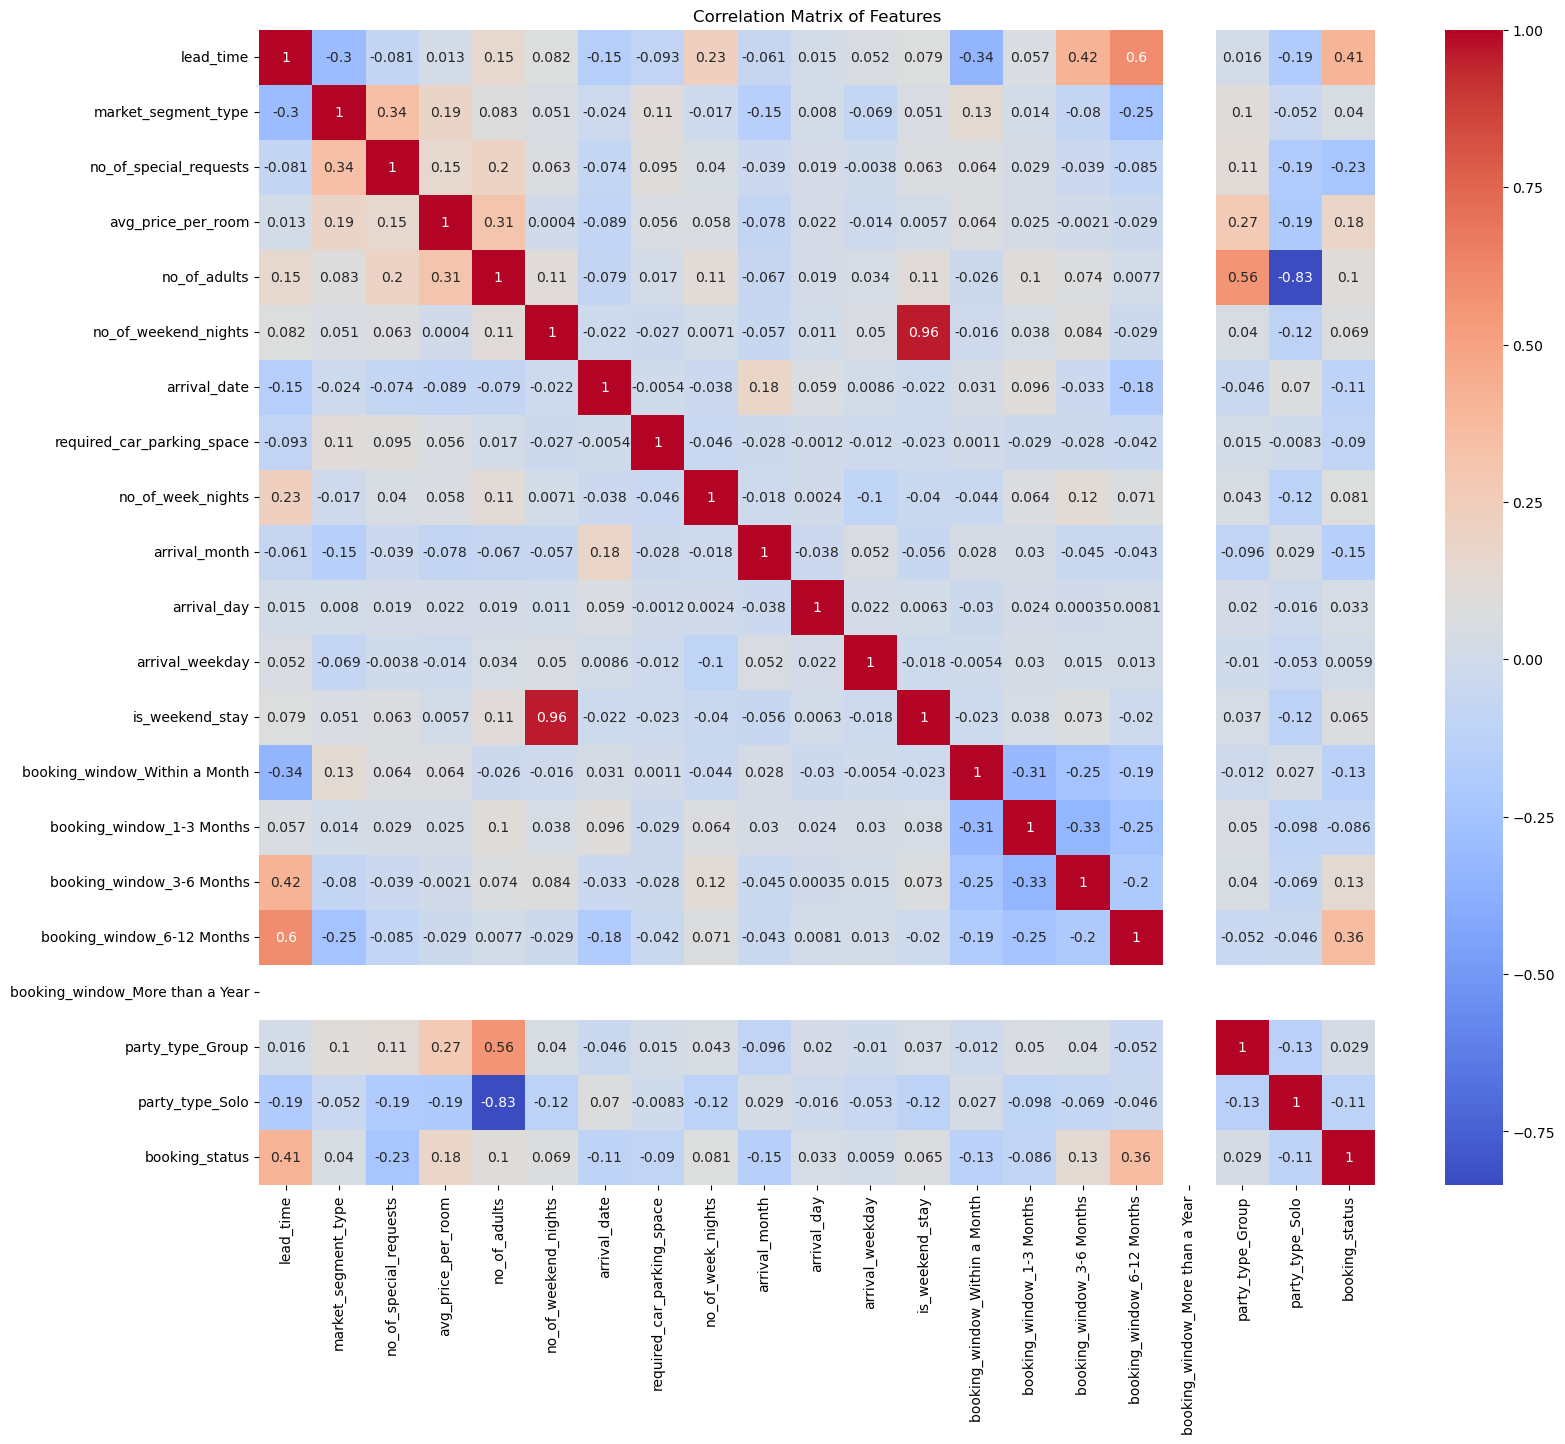

Correlation with Target Variable (booking_status):
booking_status                     1.000000
lead_time                          0.405221
booking_window_6-12 Months         0.358548
no_of_special_requests             0.233378
avg_price_per_room                 0.177261
arrival_month                      0.149731
booking_window_3-6 Months          0.128893
booking_window_Within a Month      0.127434
party_type_Solo                    0.111036
arrival_date                       0.109707
no_of_adults                       0.102766
required_car_parking_space         0.089593
booking_window_1-3 Months          0.086493
no_of_week_nights                  0.080835
no_of_weekend_nights               0.069116
is_weekend_stay                    0.065063
market_segment_type                0.039681
arrival_day                        0.033210
party_type_Group                   0.029467
arrival_weekday                    0.005903
booking_window_More than a Year         NaN
Name: booking_status, dty

In [205]:
# Combine X_train with y_train
train_with_target = X_train.copy()
train_with_target['booking_status'] = y_train

# Calculate correlation matrix again (with target included)
corr_matrix = train_with_target.corr()

# Plot heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

# Correlation with the target variable
print("Correlation with Target Variable (booking_status):")
print(corr_matrix['booking_status'].abs().sort_values(ascending=False))


In [116]:
corr_matrix

,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,arrival_month,...,arrival_weekday,is_weekend_stay,booking_window_Within a Month,booking_window_1-3 Months,booking_window_3-6 Months,booking_window_6-12 Months,booking_window_More than a Year,party_type_Group,party_type_Solo,booking_status
lead_time,1.000000,-0.300084,-0.080885,0.012623,0.151165,0.081930,-0.153940,-0.092969,0.232869,-0.061439,...,0.051532,0.078616,-0.342219,0.057072,0.416144,0.596358,NaN,0.016384,-0.186600,0.405221
market_segment_type,-0.300084,1.000000,0.343291,0.188216,0.082788,0.051445,-0.023562,0.106104,-0.016852,-0.153250,...,-0.069116,0.050667,0.127937,0.014160,-0.079935,-0.247842,NaN,0.102007,-0.051821,0.039681
no_of_special_requests,-0.080885,0.343291,1.000000,0.152188,0.201042,0.063000,-0.074344,0.095191,0.040349,-0.039037,...,-0.003793,0.063072,0.064236,0.028777,-0.038832,-0.084835,NaN,0.112705,-0.189178,-0.233378
avg_price_per_room,0.012623,0.188216,0.152188,1.000000,0.308095,0.000397,-0.089002,0.055822,0.057555,-0.078315,...,-0.013878,0.005727,0.064267,0.025379,-0.002078,-0.029477,NaN,0.272462,-0.192324,0.177261
no_of_adults,0.151165,0.082788,0.201042,0.308095,1.000000,0.109411,-0.079182,0.016724,0.113579,-0.067066,...,0.034202,0.109409,-0.025900,0.099938,0.073625,0.007710,NaN,0.563368,-0.834642,0.102766
no_of_weekend_nights,0.081930,0.051445,0.063000,0.000397,0.109411,1.000000,-0.022239,-0.027438,0.007135,-0.057223,...,0.049959,0.963774,-0.016416,0.037902,0.083988,-0.028689,NaN,0.040007,-0.115506,0.069116
arrival_date,-0.153940,-0.023562,-0.074344,-0.089002,-0.079182,-0.022239,1.000000,-0.005394,-0.038374,0.176131,...,0.008638,-0.022238,0.031133,0.096101,-0.033424,-0.182773,NaN,-0.046267,0.069949,-0.109707
required_car_parking_space,-0.092969,0.106104,0.095191,0.055822,0.016724,-0.027438,-0.005394,1.000000,-0.046464,-0.027577,...,-0.012009,-0.023103,0.001050,-0.028655,-0.027539,-0.041552,NaN,0.015264,-0.008274,-0.089593
no_of_week_nights,0.232869,-0.016852,0.040349,0.057555,0.113579,0.007135,-0.038374,-0.046464,1.000000,-0.017914,...,-0.103564,-0.039907,-0.044013,0.064013,0.118767,0.070864,NaN,0.042787,-0.122856,0.080835
arrival_month,-0.061439,-0.153250,-0.039037,-0.078315,-0.067066,-0.057223,0.176131,-0.027577,-0.017914,1.000000,...,0.052037,-0.055805,0.027569,0.029833,-0.044508,-0.042538,NaN,-0.096210,0.028511,-0.149731


In [279]:
X_train.head()

,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,arrival_date,required_car_parking_space,no_of_week_nights,arrival_month,arrival_day,arrival_weekday,is_weekend_stay,booking_window_Within a Month,booking_window_1-3 Months,booking_window_3-6 Months,booking_window_6-12 Months,booking_window_More than a Year,party_type_Group,party_type_Solo
booking_id,,,,,,,,,,,,,,,,,,,,
INNHG_101034,-1.901716,0.684049,-0.843743,-0.454095,-1.556561,0.589134,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,-0.483423,-0.648124,-0.514816,-0.391652,0.0,-0.249279,1.864944
INNHG_101035,-0.267753,0.684049,1.493040,0.724648,0.299898,1.289060,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,-0.483423,1.542914,-0.514816,-0.391652,0.0,-0.249279,-0.536209
INNHG_101036,-0.493845,0.684049,1.017350,-0.855214,0.299898,1.289060,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,2.068582,-0.648124,-0.514816,-0.391652,0.0,-0.249279,-0.536209
INNHG_101037,-0.519968,0.684049,-0.843743,-0.463956,-1.556561,1.289060,2021-01-01,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,2.068582,-0.648124,-0.514816,-0.391652,0.0,-0.249279,1.864944
INNHG_101038,-0.052915,0.684049,1.017350,1.424782,0.299898,1.289060,2021-01-01,-0.172402,0.731853,-1.865129,-1.927705,0.519416,0.961468,-0.483423,1.542914,-0.514816,-0.391652,0.0,-0.249279,-0.536209


In [281]:


date_cols_to_drop = ['arrival_date'] 
X_train = X_train.drop(columns=date_cols_to_drop)
X_test = X_test.drop(columns=date_cols_to_drop)

print("Date column(s) dropped successfully.")
X_train.head()

Date column(s) dropped successfully.


,lead_time,market_segment_type,no_of_special_requests,avg_price_per_room,no_of_adults,no_of_weekend_nights,required_car_parking_space,no_of_week_nights,arrival_month,arrival_day,arrival_weekday,is_weekend_stay,booking_window_Within a Month,booking_window_1-3 Months,booking_window_3-6 Months,booking_window_6-12 Months,booking_window_More than a Year,party_type_Group,party_type_Solo
booking_id,,,,,,,,,,,,,,,,,,,
INNHG_101034,-1.901716,0.684049,-0.843743,-0.454095,-1.556561,0.589134,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,-0.483423,-0.648124,-0.514816,-0.391652,0.0,-0.249279,1.864944
INNHG_101035,-0.267753,0.684049,1.493040,0.724648,0.299898,1.289060,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,-0.483423,1.542914,-0.514816,-0.391652,0.0,-0.249279,-0.536209
INNHG_101036,-0.493845,0.684049,1.017350,-0.855214,0.299898,1.289060,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,2.068582,-0.648124,-0.514816,-0.391652,0.0,-0.249279,-0.536209
INNHG_101037,-0.519968,0.684049,-0.843743,-0.463956,-1.556561,1.289060,-0.172402,-2.141047,-1.865129,-1.927705,0.519416,0.961468,2.068582,-0.648124,-0.514816,-0.391652,0.0,-0.249279,1.864944
INNHG_101038,-0.052915,0.684049,1.017350,1.424782,0.299898,1.289060,-0.172402,0.731853,-1.865129,-1.927705,0.519416,0.961468,-0.483423,1.542914,-0.514816,-0.391652,0.0,-0.249279,-0.536209


## Modelling

In [283]:
import pandas as pd
import numpy as np
import time

# Preprocessing and Sampling
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    fbeta_score
)

import warnings
warnings.filterwarnings('ignore')


## 1. Evaluation Function
def model_evaluation(y_true, y_pred, y_proba):
    """
    Calculates and returns a dictionary of performance metrics.
    """
    report = classification_report(y_true, y_pred, output_dict=True)
    metrics = {
        'ROC-AUC': roc_auc_score(y_true, y_proba[:, 1]),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision(1)': report['1']['precision'],
        'Recall(1)': report['1']['recall'],
        'F1-Score(1)': report['1']['f1-score'],
        'Precision(0)': report['0']['precision'],
        'Recall(0)': report['0']['recall'],
        'F1-Score(0)': report['0']['f1-score'],
        'F2-Score(1)': fbeta_score(y_true, y_pred, beta=2) # Emphasizes recall
    }
    return metrics

## 2. Define Models, Samplers, and Hyperparameter Grids

# Models to be used
models = {
    'Logistic Regression': {'model': LogisticRegression(random_state=42, max_iter=1000), 'search_type': 'grid'},
    'LDA': {'model': LinearDiscriminantAnalysis(), 'search_type': 'grid'},
    'Decision Tree': {'model': DecisionTreeClassifier(random_state=42), 'search_type': 'grid'},
    'Random Forest': {'model': RandomForestClassifier(random_state=42, n_jobs=-1), 'search_type': 'random'},
    'AdaBoost': {'model': AdaBoostClassifier(random_state=42), 'search_type': 'grid'},
    'XGBoost': {'model': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), 'search_type': 'random'},
    'LightGBM': {'model': LGBMClassifier(random_state=42, n_jobs=-1), 'search_type': 'random'},
    'CatBoost': {'model': CatBoostClassifier(random_state=42, verbose=0), 'search_type': 'random'},
    'MLPClassifier': {'model': MLPClassifier(random_state=42, max_iter=500), 'search_type': 'random'}
}

# Hyperparameter grids (comprehensive)
params = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    'LDA': {'solver': ['svd', 'lsqr', 'eigen'], 'shrinkage': [None, 'auto', 0.1, 0.5, 0.9]},
    'Decision Tree': {'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]},
    'Random Forest': {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 20, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']},
    'AdaBoost': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]},
    'XGBoost': {'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7], 'subsample': [0.7, 0.8, 0.9], 'colsample_bytree': [0.7, 0.8, 0.9]},
    'LightGBM': {'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7], 'num_leaves': [20, 31, 40], 'subsample': [0.7, 0.8, 0.9], 'colsample_bytree': [0.7, 0.8, 0.9]},
    'CatBoost': {'iterations': [100, 200, 300], 'learning_rate': [0.01, 0.1, 0.2], 'depth': [3, 5, 7], 'l2_leaf_reg': [1, 3, 5, 7]},
    'MLPClassifier': {'hidden_layer_sizes': [(50,), (100,), (50, 50)], 'activation': ['relu', 'tanh'], 'solver': ['adam'], 'alpha': [0.0001, 0.001, 0.01]}
}

# Sampling techniques
samplers = {
    'Original': None,
    'SMOTE': SMOTE(random_state=42),
    'UnderSampler': RandomUnderSampler(random_state=42)
}

# Thresholds to test
thresholds = [0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65]

## 3. Main Training and Evaluation Loop

results_list = []
best_params_list = []

for sampler_name, sampler in samplers.items():
    print(f"--- Starting evaluations for Sampler: {sampler_name} ---")
    
    # Apply sampler
    X_train_sampled, y_train_sampled = (sampler.fit_resample(X_train, y_train) 
                                        if sampler is not None 
                                        else (X_train, y_train))
    
    for model_name in models.keys():
        start_time = time.time()
        print(f"  > Processing Model: {model_name}")
        
        model = models[model_name]['model']
        
        # --- PHASE 1: Baseline Model ---
        model.fit(X_train_sampled, y_train_sampled)
        y_proba = model.predict_proba(X_test)
        
        for thresh in thresholds:
            y_pred = (y_proba[:, 1] >= thresh).astype(int)
            metrics = model_evaluation(y_test, y_pred, y_proba)
            metrics.update({
                'Model': model_name,
                'Sampler': sampler_name,
                'Tuning Stage': 'Baseline',
                'Threshold': round(thresh, 2)
            })
            results_list.append(metrics)
            
        # --- PHASE 2: Hyperparameter Tuning ---
        search_type = models[model_name]['search_type']
        
        if search_type == 'grid':
            search = GridSearchCV(model, params[model_name], cv=3, scoring='f1_weighted', n_jobs=-1)
        else: # 'random'
            search = RandomizedSearchCV(model, params[model_name], n_iter=20, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42)

        search.fit(X_train_sampled, y_train_sampled)
        
        # Store top 3 hyperparameter combinations
        cv_results_df = pd.DataFrame(search.cv_results_).sort_values(by='rank_test_score').head(3)
        for i in range(len(cv_results_df)):
            best_params_list.append({
                'Model': model_name,
                'Sampler': sampler_name,
                'Rank': i + 1,
                'Best Params': cv_results_df.iloc[i]['params'],
                'Mean Test Score': cv_results_df.iloc[i]['mean_test_score']
            })

        best_model = search.best_estimator_

        # --- PHASE 3: Tuned Model Evaluation ---
        y_proba_tuned = best_model.predict_proba(X_test)
        
        for thresh in thresholds:
            y_pred_tuned = (y_proba_tuned[:, 1] >= thresh).astype(int)
            metrics_tuned = model_evaluation(y_test, y_pred_tuned, y_proba_tuned)
            metrics_tuned.update({
                'Model': model_name,
                'Sampler': sampler_name,
                'Tuning Stage': 'Tuned',
                'Threshold': round(thresh, 2)
            })
            results_list.append(metrics_tuned)
            
        end_time = time.time()
        print(f"    Completed {model_name} with {sampler_name} in {end_time - start_time:.2f} seconds.")

## 4. Final Results
print("\n--- All modeling pipelines complete. ---")

# Create final DataFrames
results_df = pd.DataFrame(results_list)
best_params_df = pd.DataFrame(best_params_list)

# Reorder columns for better readability
cols_order = ['Model', 'Sampler', 'Tuning Stage', 'Threshold', 'ROC-AUC', 'Accuracy', 
              'F1-Score(1)', 'Precision(1)', 'Recall(1)', 
              'F1-Score(0)', 'Precision(0)', 'Recall(0)', 'F2-Score(1)']
results_df = results_df[cols_order]

--- Starting evaluations for Sampler: Original ---
  > Processing Model: Logistic Regression
    Completed Logistic Regression with Original in 12.10 seconds.
  > Processing Model: LDA
    Completed LDA with Original in 2.24 seconds.
  > Processing Model: Decision Tree
    Completed Decision Tree with Original in 10.45 seconds.
  > Processing Model: Random Forest
    Completed Random Forest with Original in 40.03 seconds.
  > Processing Model: AdaBoost
    Completed AdaBoost with Original in 15.18 seconds.
  > Processing Model: XGBoost
    Completed XGBoost with Original in 12.75 seconds.
  > Processing Model: LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 8856, number of negative: 18236
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003249 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 609
[LightGBM] [Info] Number of 

In [285]:
# Display the performance results of all models
print("\n--- Model Performance Results ---")
display(results_df.sort_values(by='F1-Score(1)', ascending=False).head(15))

# Display the best hyperparameter combinations found
print("\n--- Best Hyperparameter Combinations ---")
display(best_params_df)


--- Model Performance Results ---


,Model,Sampler,Tuning Stage,Threshold,ROC-AUC,Accuracy,F1-Score(1),Precision(1),Recall(1),F1-Score(0),Precision(0),Recall(0),F2-Score(1)
80,XGBoost,Original,Tuned,0.50,0.887299,0.851800,0.760054,0.830207,0.700833,0.892792,0.860311,0.927822,0.723379
79,XGBoost,Original,Tuned,0.45,0.887299,0.843985,0.755575,0.794848,0.720000,0.885427,0.865385,0.906420,0.733820
167,Decision Tree,SMOTE,Tuned,0.65,0.870164,0.837008,0.752122,0.766436,0.738333,0.878586,0.870622,0.886697,0.743788
81,XGBoost,Original,Tuned,0.55,0.887299,0.852917,0.750119,0.870187,0.659167,0.895788,0.847046,0.950483,0.692766
36,Decision Tree,Original,Tuned,0.40,0.879790,0.829752,0.747934,0.741803,0.754167,0.871471,0.875159,0.867814,0.751661
92,LightGBM,Original,Tuned,0.40,0.882472,0.838124,0.745837,0.786506,0.709167,0.881245,0.860456,0.903063,0.723393
93,LightGBM,Original,Tuned,0.45,0.882472,0.844265,0.745438,0.823589,0.680833,0.887817,0.852181,0.926563,0.705283
78,XGBoost,Original,Tuned,0.40,0.887299,0.829752,0.744128,0.749155,0.739167,0.872438,0.869529,0.875367,0.741143
107,CatBoost,Original,Tuned,0.45,0.882036,0.830310,0.743676,0.752560,0.735000,0.873175,0.868105,0.878305,0.738446
52,Random Forest,Original,Tuned,0.50,0.857501,0.847614,0.742938,0.853896,0.657500,0.891710,0.845431,0.943349,0.689203



--- Best Hyperparameter Combinations ---


,Model,Sampler,Rank,Best Params,Mean Test Score
0,Logistic Regression,Original,1,"{'C': 0.1, 'penalty': 'l1', 'solver': 'libline...",0.773930
1,Logistic Regression,Original,2,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.772942
2,Logistic Regression,Original,3,"{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}",0.772889
3,LDA,Original,1,"{'shrinkage': 'auto', 'solver': 'lsqr'}",0.769664
4,LDA,Original,2,"{'shrinkage': 'auto', 'solver': 'eigen'}",0.769664
...,...,...,...,...,...
76,CatBoost,UnderSampler,2,"{'learning_rate': 0.01, 'l2_leaf_reg': 5, 'ite...",0.674593
77,CatBoost,UnderSampler,3,"{'learning_rate': 0.01, 'l2_leaf_reg': 7, 'ite...",0.673452
78,MLPClassifier,UnderSampler,1,"{'solver': 'adam', 'hidden_layer_sizes': (50,)...",0.638542
79,MLPClassifier,UnderSampler,2,"{'solver': 'adam', 'hidden_layer_sizes': (50,)...",0.626039


In [287]:
best_params_df.head(81)

,Model,Sampler,Rank,Best Params,Mean Test Score
0,Logistic Regression,Original,1,"{'C': 0.1, 'penalty': 'l1', 'solver': 'libline...",0.773930
1,Logistic Regression,Original,2,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.772942
2,Logistic Regression,Original,3,"{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}",0.772889
3,LDA,Original,1,"{'shrinkage': 'auto', 'solver': 'lsqr'}",0.769664
4,LDA,Original,2,"{'shrinkage': 'auto', 'solver': 'eigen'}",0.769664
...,...,...,...,...,...
76,CatBoost,UnderSampler,2,"{'learning_rate': 0.01, 'l2_leaf_reg': 5, 'ite...",0.674593
77,CatBoost,UnderSampler,3,"{'learning_rate': 0.01, 'l2_leaf_reg': 7, 'ite...",0.673452
78,MLPClassifier,UnderSampler,1,"{'solver': 'adam', 'hidden_layer_sizes': (50,)...",0.638542
79,MLPClassifier,UnderSampler,2,"{'solver': 'adam', 'hidden_layer_sizes': (50,)...",0.626039


In [309]:
results_df.sort_values(by='Recall(1)', ascending=False).head(40)

,Model,Sampler,Tuning Stage,Threshold,ROC-AUC,Accuracy,F1-Score(1),Precision(1),Recall(1),F1-Score(0),Precision(0),Recall(0),F2-Score(1)
189,AdaBoost,SMOTE,Tuned,0.35,0.827875,0.449065,0.546207,0.377143,0.990000,0.299006,0.972286,0.176668,0.747170
182,AdaBoost,SMOTE,Baseline,0.35,0.827875,0.449065,0.546207,0.377143,0.990000,0.299006,0.972286,0.176668,0.747170
308,AdaBoost,UnderSampler,Baseline,0.35,0.819663,0.481161,0.560208,0.391146,0.986667,0.367472,0.971223,0.226605,0.756356
315,AdaBoost,UnderSampler,Tuned,0.35,0.819663,0.481161,0.560208,0.391146,0.986667,0.367472,0.971223,0.226605,0.756356
63,AdaBoost,Original,Tuned,0.35,0.852507,0.489255,0.563454,0.394719,0.984167,0.384667,0.967851,0.240034,0.757829
56,AdaBoost,Original,Baseline,0.35,0.852507,0.489255,0.563454,0.394719,0.984167,0.384667,0.967851,0.240034,0.757829
343,LightGBM,UnderSampler,Tuned,0.35,0.879538,0.582194,0.610461,0.443814,0.977500,0.549503,0.971277,0.383131,0.787989
183,AdaBoost,SMOTE,Baseline,0.40,0.827875,0.559308,0.594192,0.429580,0.963333,0.517863,0.950673,0.355854,0.771593
190,AdaBoost,SMOTE,Tuned,0.40,0.827875,0.559308,0.594192,0.429580,0.963333,0.517863,0.950673,0.355854,0.771593
217,LightGBM,SMOTE,Tuned,0.35,0.873975,0.631594,0.629005,0.474555,0.932500,0.634146,0.933878,0.480067,0.781643


In [311]:
results_df.sort_values(by='F1-Score(1)', ascending=False).head(30)

,Model,Sampler,Tuning Stage,Threshold,ROC-AUC,Accuracy,F1-Score(1),Precision(1),Recall(1),F1-Score(0),Precision(0),Recall(0),F2-Score(1)
80,XGBoost,Original,Tuned,0.50,0.887299,0.851800,0.760054,0.830207,0.700833,0.892792,0.860311,0.927822,0.723379
79,XGBoost,Original,Tuned,0.45,0.887299,0.843985,0.755575,0.794848,0.720000,0.885427,0.865385,0.906420,0.733820
167,Decision Tree,SMOTE,Tuned,0.65,0.870164,0.837008,0.752122,0.766436,0.738333,0.878586,0.870622,0.886697,0.743788
81,XGBoost,Original,Tuned,0.55,0.887299,0.852917,0.750119,0.870187,0.659167,0.895788,0.847046,0.950483,0.692766
36,Decision Tree,Original,Tuned,0.40,0.879790,0.829752,0.747934,0.741803,0.754167,0.871471,0.875159,0.867814,0.751661
92,LightGBM,Original,Tuned,0.40,0.882472,0.838124,0.745837,0.786506,0.709167,0.881245,0.860456,0.903063,0.723393
93,LightGBM,Original,Tuned,0.45,0.882472,0.844265,0.745438,0.823589,0.680833,0.887817,0.852181,0.926563,0.705283
78,XGBoost,Original,Tuned,0.40,0.887299,0.829752,0.744128,0.749155,0.739167,0.872438,0.869529,0.875367,0.741143
107,CatBoost,Original,Tuned,0.45,0.882036,0.830310,0.743676,0.752560,0.735000,0.873175,0.868105,0.878305,0.738446
52,Random Forest,Original,Tuned,0.50,0.857501,0.847614,0.742938,0.853896,0.657500,0.891710,0.845431,0.943349,0.689203


In [313]:
results_df.sort_values(by='F2-Score(1)', ascending=False).head(30)

,Model,Sampler,Tuning Stage,Threshold,ROC-AUC,Accuracy,F1-Score(1),Precision(1),Recall(1),F1-Score(0),Precision(0),Recall(0),F2-Score(1)
343,LightGBM,UnderSampler,Tuned,0.35,0.879538,0.582194,0.610461,0.443814,0.977500,0.549503,0.971277,0.383131,0.787989
344,LightGBM,UnderSampler,Tuned,0.40,0.879538,0.642199,0.634966,0.482266,0.929167,0.649152,0.933124,0.497692,0.783886
217,LightGBM,SMOTE,Tuned,0.35,0.873975,0.631594,0.629005,0.474555,0.932500,0.634146,0.933878,0.480067,0.781643
203,XGBoost,SMOTE,Tuned,0.35,0.867289,0.667318,0.645870,0.501847,0.905833,0.686316,0.920254,0.547209,0.780218
350,CatBoost,UnderSampler,Baseline,0.35,0.873171,0.671783,0.647271,0.505623,0.899167,0.693111,0.916494,0.557281,0.778050
204,XGBoost,SMOTE,Tuned,0.40,0.867289,0.712252,0.669445,0.544033,0.870000,0.745243,0.906250,0.632816,0.776901
351,CatBoost,UnderSampler,Baseline,0.40,0.873171,0.689646,0.656153,0.521632,0.884167,0.717192,0.910265,0.591691,0.776266
161,Decision Tree,SMOTE,Tuned,0.35,0.870164,0.706391,0.665394,0.538066,0.871667,0.738439,0.906040,0.623164,0.775504
162,Decision Tree,SMOTE,Tuned,0.40,0.870164,0.706391,0.665394,0.538066,0.871667,0.738439,0.906040,0.623164,0.775504
232,CatBoost,SMOTE,Tuned,0.40,0.853522,0.695786,0.658949,0.527555,0.877500,0.725441,0.907372,0.604280,0.774720


In [315]:
results_df.sort_values(by='ROC-AUC', ascending=False).head(30)

,Model,Sampler,Tuning Stage,Threshold,ROC-AUC,Accuracy,F1-Score(1),Precision(1),Recall(1),F1-Score(0),Precision(0),Recall(0),F2-Score(1)
80,XGBoost,Original,Tuned,0.50,0.887299,0.851800,0.760054,0.830207,0.700833,0.892792,0.860311,0.927822,0.723379
77,XGBoost,Original,Tuned,0.35,0.887299,0.804354,0.723034,0.687453,0.762500,0.848759,0.873446,0.825430,0.746208
78,XGBoost,Original,Tuned,0.40,0.887299,0.829752,0.744128,0.749155,0.739167,0.872438,0.869529,0.875367,0.741143
79,XGBoost,Original,Tuned,0.45,0.887299,0.843985,0.755575,0.794848,0.720000,0.885427,0.865385,0.906420,0.733820
81,XGBoost,Original,Tuned,0.55,0.887299,0.852917,0.750119,0.870187,0.659167,0.895788,0.847046,0.950483,0.692766
82,XGBoost,Original,Tuned,0.60,0.887299,0.849009,0.735193,0.890866,0.625833,0.894398,0.836131,0.961393,0.665426
83,XGBoost,Original,Tuned,0.65,0.887299,0.827798,0.674062,0.920635,0.531667,0.882989,0.805536,0.976920,0.580739
97,LightGBM,Original,Tuned,0.65,0.882472,0.744627,0.383838,1.000000,0.237500,0.838937,0.722559,1.000000,0.280236
91,LightGBM,Original,Tuned,0.35,0.882472,0.822774,0.737278,0.732128,0.742500,0.866288,0.869400,0.863198,0.740402
92,LightGBM,Original,Tuned,0.40,0.882472,0.838124,0.745837,0.786506,0.709167,0.881245,0.860456,0.903063,0.723393


In [319]:
filtered_results = results_df[
    (results_df['Recall(1)'] > 0.8) &
    (results_df['ROC-AUC'] > 0.83) &
    (results_df['F1-Score(1)'] > 0.63) &
    (results_df['F2-Score(1)'] > 0.6)
]

# Sort the results by the F2-Score for better readability
sorted_filtered_results = filtered_results.sort_values(by='Recall(1)', ascending=False)

# Display the final filtered and sorted DataFrame
sorted_filtered_results

,Model,Sampler,Tuning Stage,Threshold,ROC-AUC,Accuracy,F1-Score(1),Precision(1),Recall(1),F1-Score(0),Precision(0),Recall(0),F2-Score(1)
344,LightGBM,UnderSampler,Tuned,0.40,0.879538,0.642199,0.634966,0.482266,0.929167,0.649152,0.933124,0.497692,0.783886
203,XGBoost,SMOTE,Tuned,0.35,0.867289,0.667318,0.645870,0.501847,0.905833,0.686316,0.920254,0.547209,0.780218
329,XGBoost,UnderSampler,Tuned,0.35,0.869406,0.656433,0.637194,0.492932,0.900833,0.673734,0.914388,0.533361,0.772916
350,CatBoost,UnderSampler,Baseline,0.35,0.873171,0.671783,0.647271,0.505623,0.899167,0.693111,0.916494,0.557281,0.778050
322,XGBoost,UnderSampler,Baseline,0.35,0.862495,0.656433,0.634393,0.492847,0.890000,0.675967,0.906780,0.538817,0.766471
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,AdaBoost,Original,Baseline,0.45,0.852507,0.757466,0.689532,0.603502,0.804167,0.801008,0.881552,0.733949,0.754024
341,LightGBM,UnderSampler,Baseline,0.60,0.874281,0.746302,0.679591,0.588882,0.803333,0.790021,0.878726,0.717583,0.748796
255,Logistic Regression,UnderSampler,Baseline,0.50,0.843034,0.757466,0.689088,0.603762,0.802500,0.801190,0.880785,0.734788,0.752932
35,Decision Tree,Original,Tuned,0.35,0.879790,0.801842,0.730653,0.670613,0.802500,0.843267,0.889613,0.801511,0.772130


In [ ]:
# We will be choosing 344 LightGBM as the final model, as it has a good Recall(1) of 92.91%, a high F2-Score(1) and a high ROC-AUC of 87.95%, and it
# is a balanced model.

In [323]:
best_params_df[best_params_df['Model']=='LightGBM']

,Model,Sampler,Rank,Best Params,Mean Test Score
18,LightGBM,Original,1,"{'subsample': 0.9, 'num_leaves': 31, 'n_estima...",0.728752
19,LightGBM,Original,2,"{'subsample': 0.9, 'num_leaves': 20, 'n_estima...",0.720687
20,LightGBM,Original,3,"{'subsample': 0.7, 'num_leaves': 20, 'n_estima...",0.718188
45,LightGBM,SMOTE,1,"{'subsample': 0.9, 'num_leaves': 31, 'n_estima...",0.661097
46,LightGBM,SMOTE,2,"{'subsample': 0.7, 'num_leaves': 40, 'n_estima...",0.655234
47,LightGBM,SMOTE,3,"{'subsample': 0.7, 'num_leaves': 40, 'n_estima...",0.653404
72,LightGBM,UnderSampler,1,"{'subsample': 0.7, 'num_leaves': 40, 'n_estima...",0.656618
73,LightGBM,UnderSampler,2,"{'subsample': 0.9, 'num_leaves': 31, 'n_estima...",0.654879
74,LightGBM,UnderSampler,3,"{'subsample': 0.7, 'num_leaves': 20, 'n_estima...",0.652590


In [333]:
# Extracting the exact configuration of the desired LightGBM model with 0.4 threshold.

a=best_params_df[
    (best_params_df['Model'] == 'LightGBM') &
    (best_params_df['Sampler'] == 'UnderSampler') &
    (best_params_df['Rank'] == 1)
]
pd.set_option('display.max_colwidth', None)
print(a['Best Params'])

72    {'subsample': 0.7, 'num_leaves': 40, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Name: Best Params, dtype: object


## Fitting the final model

In [338]:
import joblib
final_params = {
    'subsample': 0.7, 
    'num_leaves': 40, 
    'n_estimators': 100, 
    'max_depth': 5, 
    'learning_rate': 0.01, 
    'colsample_bytree': 0.7,
    'random_state': 42  
}

# 2. Instantiate the final model with these parameters
final_model = LGBMClassifier(**final_params)

# 3. Prepare the data with the UnderSampler
# This is a critical step to replicate the performance of your chosen model
sampler = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)

print(f"Original training data shape: {X_train.shape}")
print(f"Resampled training data shape: {X_train_resampled.shape}")

# 4. Fit the final model on the resampled training data
print("\nTraining the final model...")
final_model.fit(X_train_resampled, y_train_resampled)
print("Training complete.")

# 5. Save the trained model using joblib
model_filename = 'lgbm_hotel_cancellation_predictor_model.joblib'
joblib.dump(final_model, model_filename)

print(f"\n✅ Model successfully trained and saved to '{model_filename}'")

Original training data shape: (27092, 19)
Resampled training data shape: (17712, 19)

Training the final model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 8856, number of negative: 8856
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009778 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 611
[LightGBM] [Info] Number of data points in the train set: 17712, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [340]:
# Save the PowerTransformer
joblib.dump(pt, 'power_transformer.joblib')

# Save the StandardScaler
joblib.dump(scaler, 'scaler.joblib')

print("✅ Pre-processing objects saved successfully.")

✅ Pre-processing objects saved successfully.
